In [1]:
# Data handling
import pandas as pd
import numpy as np
import requests

In [2]:
# Visualization
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [5]:
!pip install pandas


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
!pip install matplotlib seaborn



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
DATA_DIR = "data"
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)
URLS = {
    'KDDTrain+.txt':'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt',
    'KDDTest+.txt' : 'https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt'
}

def download_file(url,filename):
    local_path = os.path.join(DATA_DIR, filename)

    if os.path.exists(local_path):
        print(f"Correct file found: {filename} already exists")
        return
    print(f"Downloading {filename}...")
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status()

        with open(local_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size = 8000):
                f.write(chunk)
        print(f"Success saved to {local_path}")
    except Exception as e:
        print(f"Failed to download {filename} :{e}")
        

In [13]:
for filename, url in URLS.items():
    download_file(url,filename)
print("\nAll files should now be in 'data' folder.")

Failed to download KDDTrain+.txt :name 'requests' is not defined
Failed to download KDDTest+.txt :name 'requests' is not defined

All files should now be in 'data' folder.


In [8]:
import pandas as pd
import os

DATA_DIR = 'data'
TRAIN_PATH = os.path.join(DATA_DIR, 'KCDTrain.txt')


COLUMNS = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", 
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", 
    "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", 
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", 
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", 
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate", 
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", 
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", 
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate", 
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "class", "difficulty_level"
]

df = pd.read_csv(TRAIN_PATH, header=None, names=COLUMNS)

df.to_csv("labeled_CSV",index=False)
df.head()
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


In [7]:
print(df.columns)

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class', 'difficulty_level'],
      dtype='str')


In [7]:
print("Dataset shape:", df.shape)   #seeing dataset shape

Dataset shape: (125973, 43)


In [12]:
train_path = os.path.join(DATA_DIR, 'KCDTrain.txt')
test_path = os.path.join(DATA_DIR, 'KCDTest.txt')

train_df = pd.read_csv(train_path, names=COLUMNS)
test_df = pd.read_csv(test_path, names=COLUMNS)

print("Data Loaded Successfully!")

Data Loaded Successfully!


In [13]:
train_df.head()
train_df.tail()
test_df.tail()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level
22539,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22540,0,tcp,http,SF,317,938,0,0,0,0,...,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22541,0,tcp,http,SF,54540,8314,0,0,0,2,...,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,back,15
22542,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,normal,21
22543,0,tcp,sunrpc,REJ,0,0,0,0,0,0,...,0.08,0.03,0.00,0.00,0.00,0.0,0.44,1.00,mscan,14


In [23]:
train_df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty_level
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [24]:
print("\n---Data Info---")
train_df.info()


---Data Info---
<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64 

In [14]:
# seeing missing values
print(f"Missing Values in teh Training Data: {train_df.isnull().sum().sum()}")
print(f"Missing Values in teh Testing Data: {test_df.isnull().sum()}")

Missing Values in teh Training Data: 0
Missing Values in teh Testing Data: duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
s

In [12]:
#seeing duplicates
print(f"Duplicate data in the training dataset {train_df.duplicated().sum()}")
print(f"Duplicate data in the test dataset {test_df.duplicated()}")

Duplicate data in the training dataset 0
Duplicate data in the test dataset 0        False
1        False
2        False
3        False
4        False
         ...  
22539    False
22540    False
22541    False
22542    False
22543    False
Length: 22544, dtype: bool


In [15]:
df = df.drop_duplicates()  #remove duplicates

In [16]:
print(df.head())   #seeing first 5 rows

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [26]:
train_df['class']

0          normal
1          normal
2         neptune
3          normal
4          normal
           ...   
125968    neptune
125969     normal
125970     normal
125971    neptune
125972     normal
Name: class, Length: 125973, dtype: str

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
unique_labels = train_df['class'].unique()
print(f" There are {len(unique_labels)} unique lables including 'normal'.")
print(unique_labels)

 There are 23 unique lables including 'normal'.
<StringArray>
[         'normal',         'neptune',     'warezclient',         'ipsweep',
       'portsweep',        'teardrop',            'nmap',           'satan',
           'smurf',             'pod',            'back',    'guess_passwd',
       'ftp_write',        'multihop',         'rootkit', 'buffer_overflow',
            'imap',     'warezmaster',             'phf',            'land',
      'loadmodule',             'spy',            'perl']
Length: 23, dtype: str


In [16]:
train_df['class'].value_counts()

class
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [17]:
import pandas as pd
df = pd.read_csv(TRAIN_PATH, header=None, names=COLUMNS)
df#first few rows displays
df.duplicated().sum()

np.int64(0)

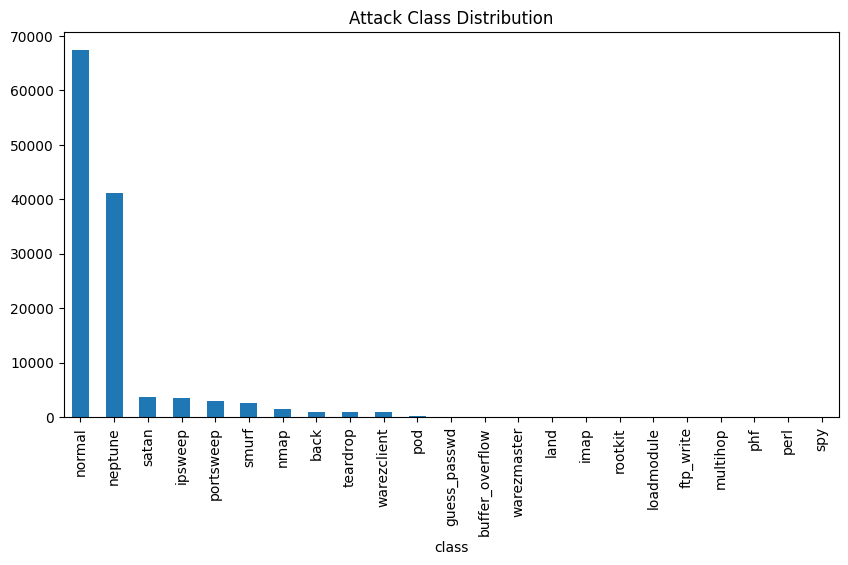

In [57]:
plt.figure(figsize=(10,5))
train_df['class'].value_counts().plot(kind='bar')
plt.title("Attack Class Distribution")#class distribution
plt.xticks(rotation=90)
plt.show()

In [21]:
df['protocol_type'].unique()
df['protocol_type']

0         tcp
1         udp
2         tcp
3         tcp
4         tcp
         ... 
125968    tcp
125969    udp
125970    tcp
125971    tcp
125972    tcp
Name: protocol_type, Length: 125973, dtype: str

In [26]:
tab = pd.read_csv(train_path, names=COLUMNS)
df.head()
df.shape
df['protocol_type']
df[(df['protocol_type'] == 'tcp') & (df['src_bytes'] > 500)]
#x.unique().sum()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level
42,2,tcp,smtp,SF,1591,372,0,0,0,0,...,0.81,0.02,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
60,0,tcp,ftp_data,SF,641,0,0,0,0,0,...,0.25,0.02,0.25,0.04,0.00,0.00,0.00,0.00,normal,21
65,0,tcp,smtp,SF,696,333,0,0,0,0,...,0.39,0.04,0.01,0.02,0.00,0.00,0.00,0.00,normal,21
95,2,tcp,smtp,SF,3065,331,0,0,0,0,...,0.48,0.02,0.00,0.02,0.01,0.02,0.00,0.00,normal,21
111,0,tcp,smtp,SF,2089,335,0,0,0,0,...,0.60,0.03,0.00,0.00,0.01,0.02,0.00,0.01,normal,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125944,1,tcp,smtp,SF,2049,362,0,0,0,0,...,0.92,0.02,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125952,0,tcp,smtp,SF,1289,408,0,0,0,0,...,0.23,0.06,0.00,0.00,0.51,0.00,0.02,0.00,normal,15
125957,1,tcp,smtp,SF,1247,327,0,0,0,0,...,0.53,0.03,0.00,0.02,0.01,0.02,0.00,0.00,normal,21
125965,0,tcp,smtp,SF,2233,365,0,0,0,0,...,1.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,normal,19


In [29]:
subset = df[['duration', 'protocol_type', 'class']]
subset.head()
df['protocol_type'].unique()

<StringArray>
['tcp', 'udp', 'icmp']
Length: 3, dtype: str

In [21]:
df['protocol_type'].unique()
df['service'].unique()
df['land'].unique()

array([0, 1])

In [20]:
# TCP Traffic
tcp_traffic = df[df['protocol_type'] == 'tcp']
print(f"Traffic of the TCP Count is: {len(tcp_traffic)}")
# UDP Traffic
udp_traffic = df[df['protocol_type'] == 'udp']
print(f"Traffic of the UDP Count is: {len(udp_traffic)}")
# ICMP Traffic
icmp_traffic = df[df['protocol_type'] == 'icmp']
print(f"Traffic of the ICMP Count is: {len(icmp_traffic)}")

Traffic of the TCP Count is: 102689
Traffic of the UDP Count is: 14993
Traffic of the ICMP Count is: 8291


In [31]:
land_attack = df[df['land']==1]
print(f"Land attacks Found are: {len(land_attack)}")

Land attacks Found are: 25


In [32]:
first_ten_rows = df.iloc[0:30]
first_ten_rows

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
5,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21
6,0,tcp,private,S0,0,0,0,0,0,0,...,0.04,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
7,0,tcp,private,S0,0,0,0,0,0,0,...,0.06,0.07,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
8,0,tcp,remote_job,S0,0,0,0,0,0,0,...,0.09,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21
9,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,21


In [33]:
df['service'].unique()

<StringArray>
[   'ftp_data',       'other',     'private',        'http',  'remote_job',
        'name',  'netbios_ns',       'eco_i',         'mtp',      'telnet',
      'finger',    'domain_u',      'supdup',   'uucp_path',      'Z39_50',
        'smtp',    'csnet_ns',        'uucp', 'netbios_dgm',       'urp_i',
        'auth',      'domain',         'ftp',         'bgp',        'ldap',
       'ecr_i',      'gopher',       'vmnet',      'systat',    'http_443',
         'efs',       'whois',       'imap4',    'iso_tsap',        'echo',
      'klogin',        'link',      'sunrpc',       'login',      'kshell',
     'sql_net',        'time',   'hostnames',        'exec',       'ntp_u',
     'discard',        'nntp',     'courier',         'ctf',         'ssh',
     'daytime',       'shell',     'netstat',       'pop_3',        'nnsp',
         'IRC',       'pop_2',     'printer',       'tim_i',     'pm_dump',
       'red_i', 'netbios_ssn',         'rje',         'X11',       'urh_i'

In [34]:
print(df['class'].value_counts())

class
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [58]:
df[df['protocol_type']=='icmp']['src_bytes']

17          18
30           8
56           8
72         181
83           8
          ... 
125927    1032
125935      30
125942      30
125947      18
125956      30
Name: src_bytes, Length: 8291, dtype: int64

In [27]:
print("Average Duration by Protocol:")
print(df.groupby('protocol_type')['duration'].mean())

print("\nStatistics by protocol (Duration):")
print(df.groupby('protocol_type')['duration'].agg(['min', 'max', 'count', 'mean']))

Average Duration by Protocol:
protocol_type
icmp      0.000000
tcp     281.386419
udp     485.372040
Name: duration, dtype: float64

Statistics by protocol (Duration):
               min    max   count        mean
protocol_type                                
icmp             0      0    8291    0.000000
tcp              0  42908  102689  281.386419
udp              0  29505   14993  485.372040


In [38]:
df['protocol_type'].unique()
df['protocol_type']

0         tcp
1         udp
2         tcp
3         tcp
4         tcp
         ... 
125968    tcp
125969    udp
125970    tcp
125971    tcp
125972    tcp
Name: protocol_type, Length: 125973, dtype: str

In [39]:
land_attack = df[df['land']==1]
print(f"Land attacks found are: {len(land_attack)}")

Land attacks found are: 25


In [41]:
protocol_counts = df['protocol_type'].value_counts()
protocol_counts

protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

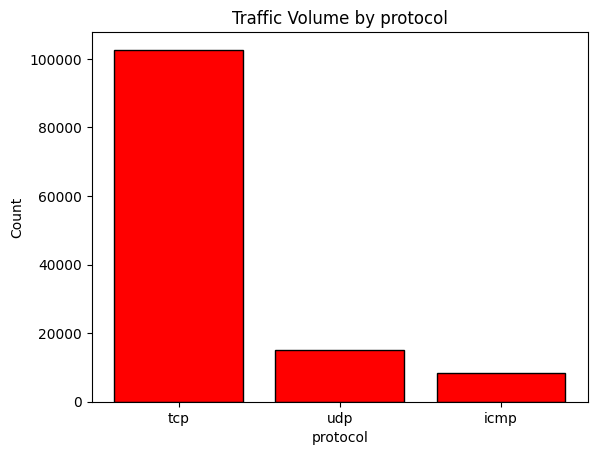

<Figure size 800x400 with 0 Axes>

In [14]:
import matplotlib.pyplot as plt
protocol_counts = df['protocol_type'].value_counts()
protocol_counts
def set_plot(title, xLabel, yLabel):
    plt.title(title)
    plt.xlabel(xLabel)
    plt.ylabel(yLabel)
    plt.figure(figsize=(8,4))
plt.bar(protocol_counts.index, protocol_counts.values, color="red", edgecolor="black")
set_plot("Traffic Volume by protocol", "protocol", "Count")
plt.show()

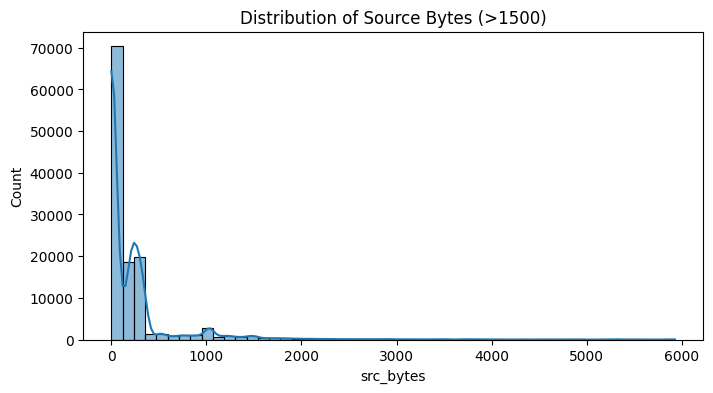

In [49]:
import seaborn as sns
small_bytes = df[df['src_bytes']<6000]
small_bytes
plt.figure(figsize=(8,4))
sns.histplot(small_bytes['src_bytes'], bins=50, kde=True)
plt.title("Distribution of Source Bytes (>1500)")
plt.show()


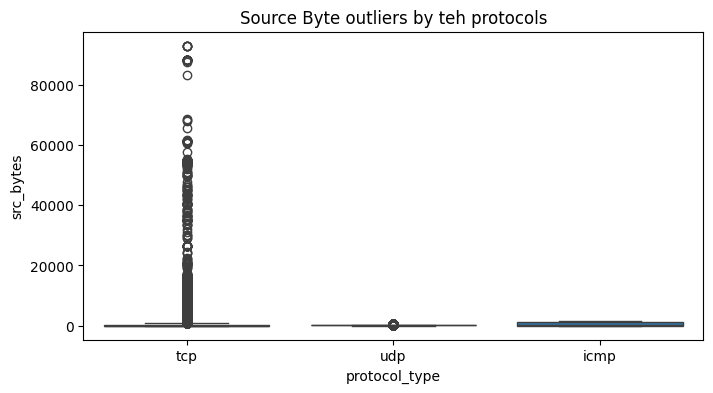

In [50]:
plt.figure(figsize = (8,4))
small_bytes = df[df['src_bytes']<100000]
sns.boxplot(x = 'protocol_type',y = 'src_bytes',data = small_bytes)
plt.title("Source Byte outliers by teh protocols")
plt.show()

In [59]:
print(df['protocol_type'].value_counts())

protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64


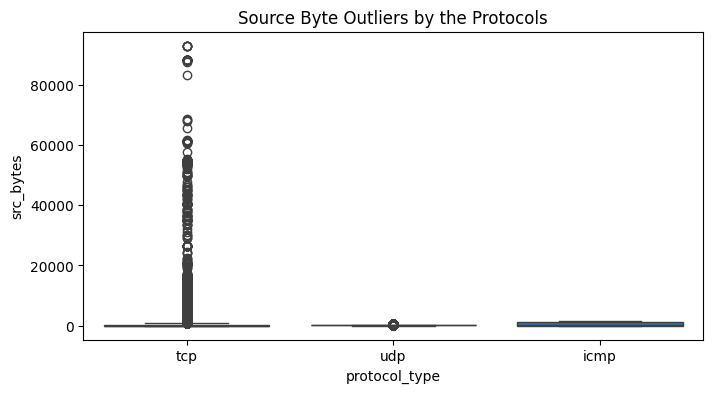

In [52]:
plt.figure(figsize=(8,4))
sns.boxplot(x="protocol_type", y="src_bytes", data=small_bytes)
plt.title("Source Byte Outliers by the Protocols")
plt.show()

In [53]:
ct = pd.crosstab(df['protocol_type'], df['flag'])
ct

flag,OTH,REJ,RSTO,RSTOS0,RSTR,S0,S1,S2,S3,SF,SH
protocol_type,,,,,,,,,,,
icmp,0,0,0,0,0,0,0,0,0,8291,0
tcp,46,11233,1562,103,2421,34851,365,127,49,51661,271
udp,0,0,0,0,0,0,0,0,0,14993,0


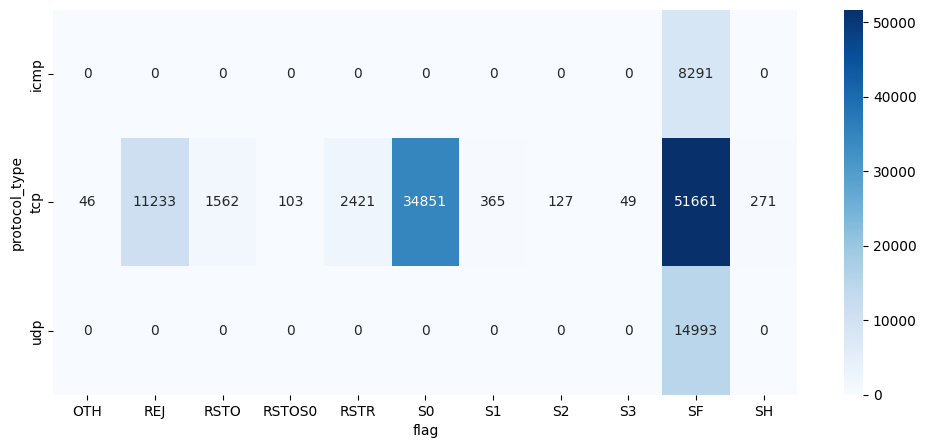

In [56]:
plt.figure(figsize=(12,5))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.show()

In [8]:
import numpy as np
log_src_bytes = np.log1p(df['src_bytes'])
log_src_bytes

0         6.198479
1         4.990433
2         0.000000
3         5.451038
4         5.298317
            ...   
125968    0.000000
125969    4.663439
125970    7.710653
125971    0.000000
125972    5.023881
Name: src_bytes, Length: 125973, dtype: float64

In [9]:
# Log(1+x)c
df['src_bytes']

0          491
1          146
2            0
3          232
4          199
          ... 
125968       0
125969     105
125970    2231
125971       0
125972     151
Name: src_bytes, Length: 125973, dtype: int64

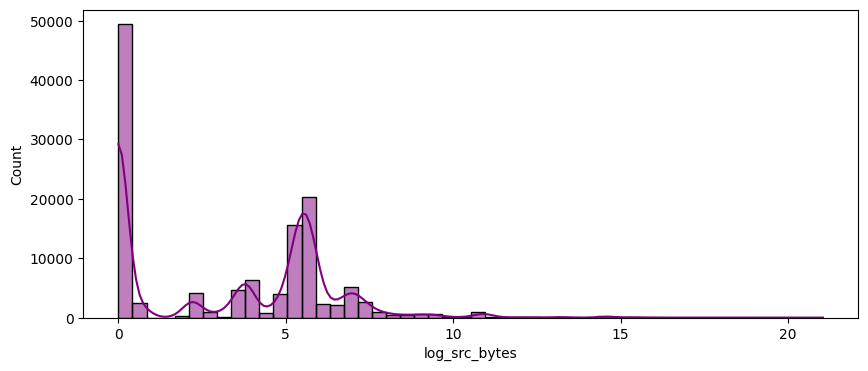

In [20]:
import numpy as np
# log(1+x)e
df['log_src_bytes'] = np.log1p(df['src_bytes'])
df['log_src_bytes']
plt.figure(figsize = (10,4))
sns.histplot(df['log_src_bytes'],bins=50,kde=True,color="purple")
plt.show()

In [21]:
numerical_cols = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count']
corr = df[numerical_cols].corr()
print("\nCorrelation Matrix:\n", corr)


Correlation Matrix:
            duration  src_bytes  dst_bytes     count  srv_count
duration   1.000000   0.070737   0.034878 -0.079042  -0.039470
src_bytes  0.070737   1.000000   0.000204 -0.005152  -0.002792
dst_bytes  0.034878   0.000204   1.000000 -0.003543  -0.001754
count     -0.079042  -0.005152  -0.003543  1.000000   0.471079
srv_count -0.039470  -0.002792  -0.001754  0.471079   1.000000


In [22]:
import numpy as np
# the 5 numerical columns
numerical_cols = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count']
new_df = df[numerical_cols].copy()
# logarithmic transformation column
new_df['log_src_bytes'] = np.log1p(new_df['src_bytes'])
print("\nNew Dataset Preview:\n", new_df.head())



New Dataset Preview:
    duration  src_bytes  dst_bytes  count  srv_count  log_src_bytes
0         0        491          0      2          2       6.198479
1         0        146          0     13          1       4.990433
2         0          0          0    123          6       0.000000
3         0        232       8153      5          5       5.451038
4         0        199        420     30         32       5.298317


In [33]:
 df.columns
 df


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


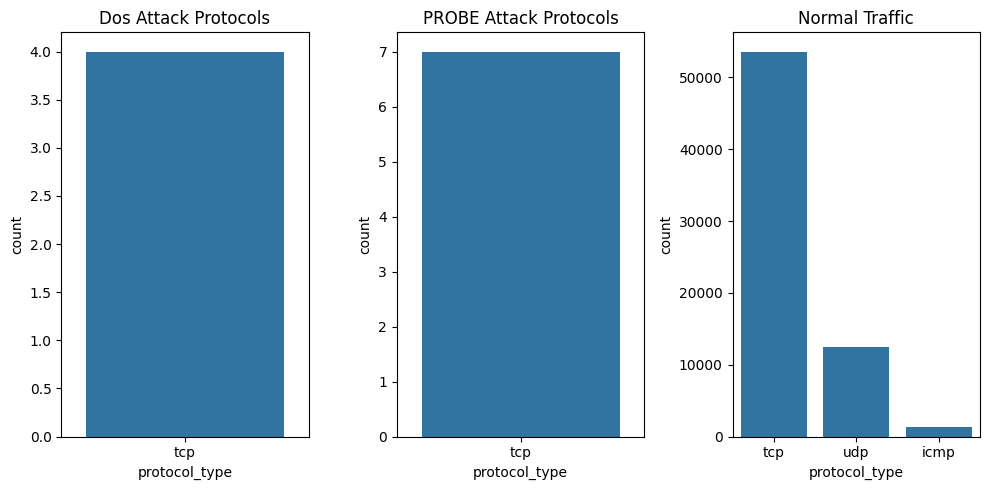

In [28]:
fig, axes = plt.subplots(1,3, figsize=(10,5))
sns.countplot(x='protocol_type', data = df[df['class'] == 'phf'],ax= axes[0])
axes[0].set_title("Dos Attack Protocols")
sns.countplot(x='protocol_type', data = df[df['class'] == 'multihop'],ax= axes[1])
axes[1].set_title("PROBE Attack Protocols")
sns.countplot(x='protocol_type', data = df[df['class'] == 'normal'],ax= axes[2])
axes[2].set_title("Normal Traffic")

plt.tight_layout()
plt.show()

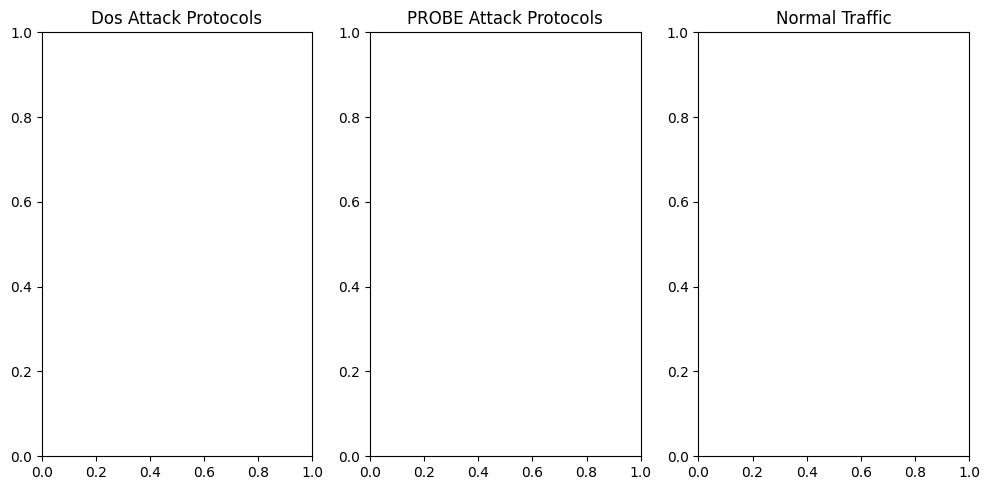

In [29]:
fig, axes = plt.subplots(1,3, figsize=(10,5))
sns.countplot(x='protocol_type', data = df[df['class'] == 'duration'],ax= axes[0])
axes[0].set_title("Dos Attack Protocols")
sns.countplot(x='protocol_type', data = df[df['class'] == 'duration'],ax= axes[1])
axes[1].set_title("PROBE Attack Protocols")
sns.countplot(x='protocol_type', data = df[df['class'] == 'duration'],ax= axes[2])
axes[2].set_title("Normal Traffic")

plt.tight_layout()
plt.show()

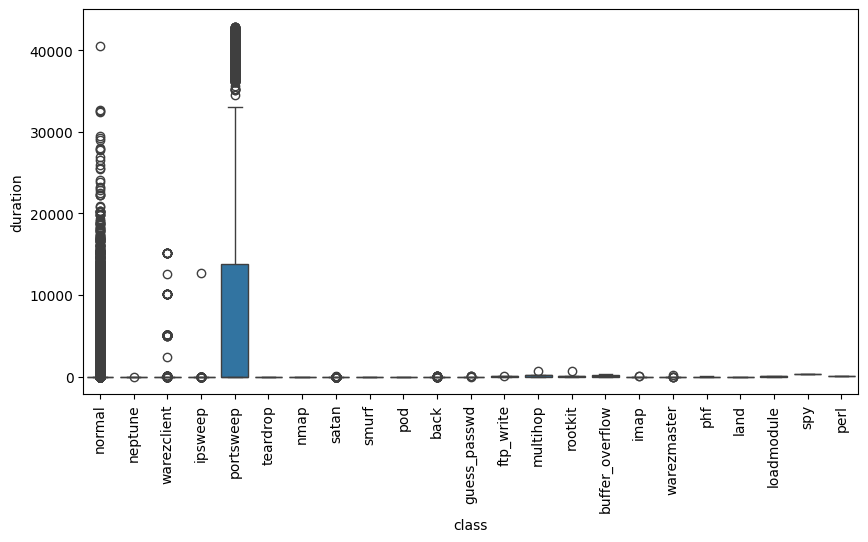

In [30]:
plt.figure(figsize=(10,5))
sns.boxplot(x='class',y='duration',data=df)
plt.xticks(rotation=90)
plt.show()

In [31]:
avg_distribution = df.groupby('class')['duration'].mean().sort_values()
avg_distribution

class
land                  0.000000
nmap                  0.000000
pod                   0.000000
smurf                 0.000000
teardrop              0.000000
neptune               0.000049
satan                 0.127718
back                  0.297071
guess_passwd          2.716981
ipsweep               3.616004
phf                   4.500000
imap                  6.545455
warezmaster          15.050000
ftp_write            32.375000
loadmodule           36.222222
perl                 41.333333
buffer_overflow      91.700000
rootkit             100.800000
normal              168.587396
multihop            184.000000
spy                 318.000000
warezclient         705.092135
portsweep          8246.697032
Name: duration, dtype: float64

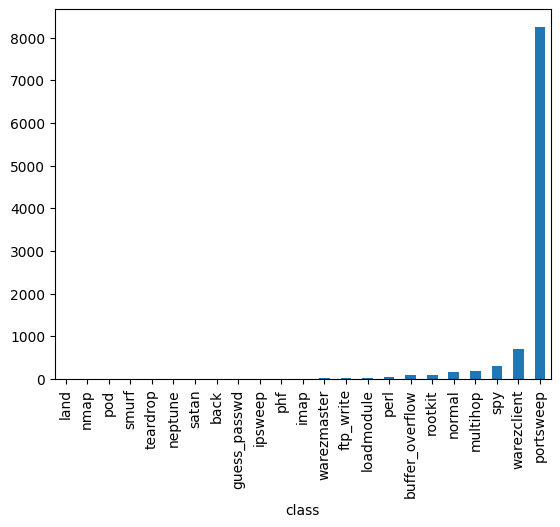

In [34]:
avg_distribution = df.groupby('class')['duration'].mean().sort_values()
avg_distribution
avg_distribution.plot(kind = 'bar')
plt.show()

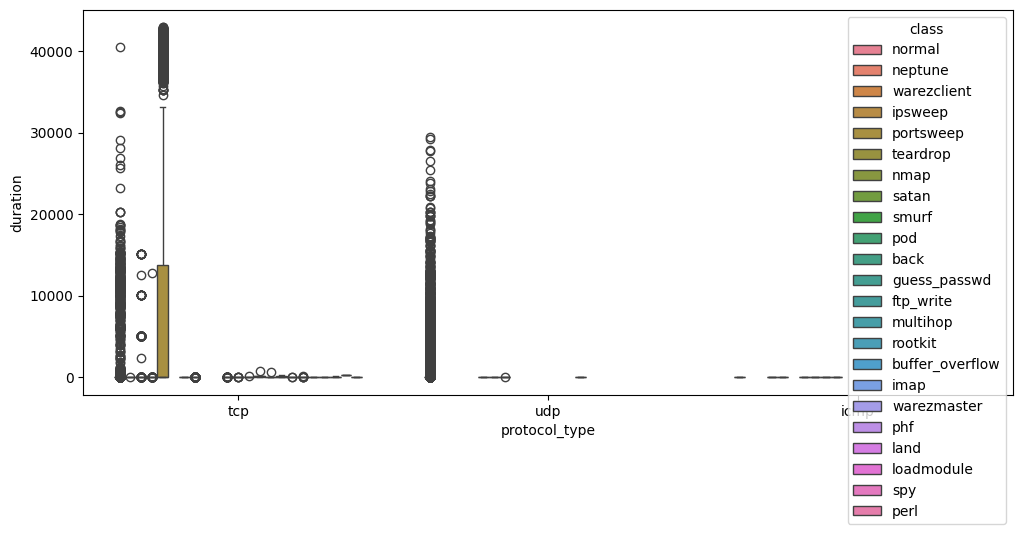

In [35]:
plt.figure(figsize=(12,5))
sns.boxplot(x = 'protocol_type',y='duration',hue='class', data = df)
plt.show()